# YOLOv8
**Классы:** Текст · Рисунок · Формула

Структура данных:
```
data/
  images/   ← .png файлы
  labels/   ← .txt файлы (YOLO format)
  classes.txt
```

## 0. Параметры

In [2]:
DATA_DIR    = "data"
MODEL_SIZE  = "yolov8n" 
EPOCHS      = 100
IMG_SIZE    = 1280
BATCH_SIZE  = 2            
VAL_SPLIT   = 0.25          
DEVICE      = 0             

## 1. Установка зависимостей

In [3]:
import os, shutil, random, yaml
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from ultralytics import YOLO

print("OK")

OK


## 2. Чтение классов и проверка данных

In [4]:
# Читаем классы из classes.txt
classes_file = Path(DATA_DIR) / "classes.txt"
CLASS_NAMES = [l.strip() for l in classes_file.read_text().splitlines() if l.strip()]
print(f"Классы ({len(CLASS_NAMES)}): {CLASS_NAMES}")

CLASS_COLORS = ["#2196F3", "#4CAF50", "#FF5722",
                "#9C27B0", "#FF9800", "#00BCD4"][:len(CLASS_NAMES)]

# Собираем пары image + label
images_dir = Path(DATA_DIR) / "images"
labels_dir = Path(DATA_DIR) / "labels"

pairs = []
for img_path in sorted(images_dir.glob("*.png")) + sorted(images_dir.glob("*.jpg")):
    lbl_path = labels_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        pairs.append((img_path, lbl_path))
    else:
        print(f"  [!] Нет разметки: {img_path.name}")

print(f"\nПар image+label: {len(pairs)}")

# Статистика по классам
all_labels = []
for _, lbl in pairs:
    for line in lbl.read_text().splitlines():
        parts = line.strip().split()
        if parts: all_labels.append(int(parts[0]))

print("\nАннотаций по классам:")
for cls, cnt in Counter(all_labels).most_common():
    print(f"  {CLASS_NAMES[cls]}: {cnt}")

Классы (3): ['formula', 'picture', 'text']

Пар image+label: 14

Аннотаций по классам:
  formula: 250
  text: 199
  picture: 56


## 3. Визуализация разметки

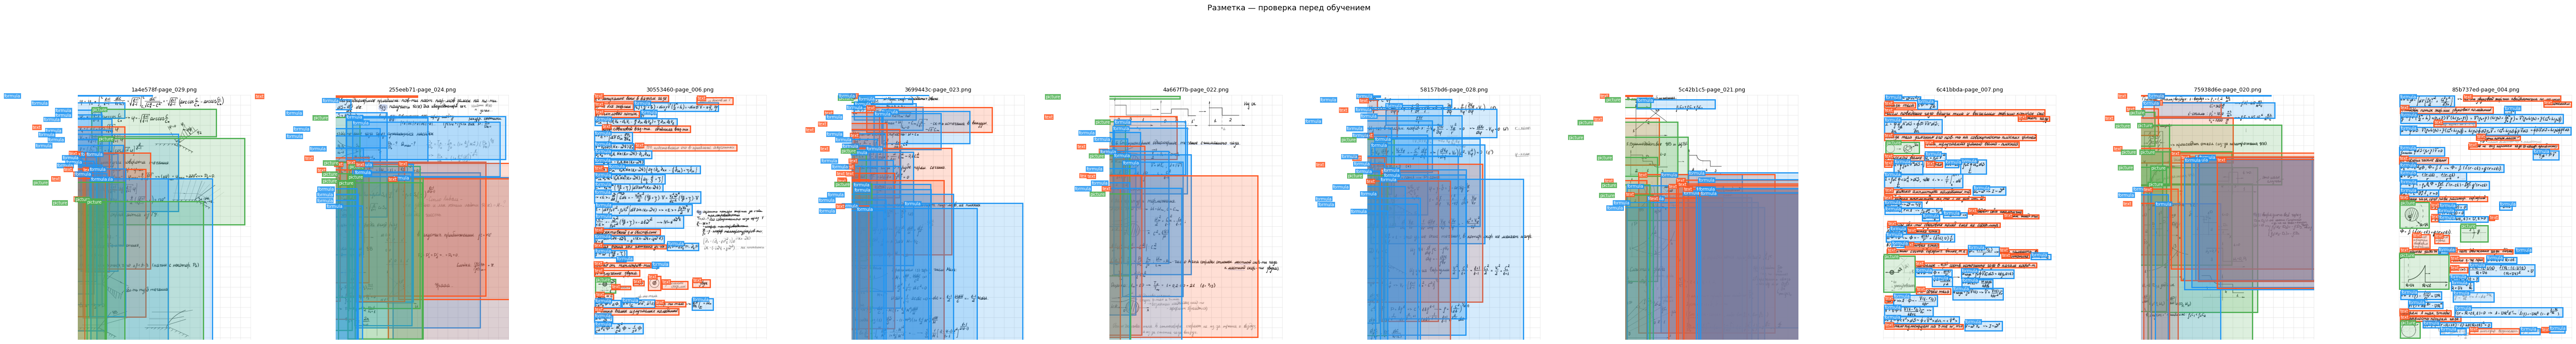

In [6]:
def show_labels(img_path, lbl_path, ax=None):
    img = Image.open(img_path)
    W, H = img.size
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 11))
    ax.imshow(img); ax.axis("off")
    ax.set_title(img_path.name, fontsize=9)
    for line in lbl_path.read_text().splitlines():
        p = line.strip().split()
        if len(p) < 5: continue
        cls = int(p[0])
        xc, yc, w, h = map(float, p[1:5])
        x0, y0 = (xc - w/2)*W, (yc - h/2)*H
        color = CLASS_COLORS[cls % len(CLASS_COLORS)]
        ax.add_patch(mpatches.Rectangle(
            (x0, y0), w*W, h*H,
            linewidth=2, edgecolor=color, facecolor=color+"30"))
        ax.text(x0+3, y0+14, CLASS_NAMES[cls], fontsize=7, color="white",
                bbox=dict(facecolor=color, alpha=0.85, pad=1, edgecolor="none"))

cols = min(len(pairs), 10)
fig, axes = plt.subplots(1, cols, figsize=(6*cols, 10))
if cols == 1: axes = [axes]
for ax, (img_path, lbl_path) in zip(axes, pairs[:cols]):
    show_labels(img_path, lbl_path, ax)
plt.suptitle("Разметка — проверка перед обучением", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Подготовка датасета (train / val split)

In [5]:
DATASET_DIR = Path("yolo_dataset")

# Чистим старый датасет если есть
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)

for split in ["train", "val"]:
    (DATASET_DIR / "images" / split).mkdir(parents=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True)

random.seed(42)
shuffled = pairs.copy()
random.shuffle(shuffled)

n_val = max(1, int(len(shuffled) * VAL_SPLIT))
val_pairs   = shuffled[:n_val]
train_pairs = shuffled[n_val:]

# Если данных мало — дублируем train в val
if len(train_pairs) == 0:
    train_pairs = val_pairs
    print("[!] Мало данных — train=val")

for split, split_pairs in [("train", train_pairs), ("val", val_pairs)]:
    for img_path, lbl_path in split_pairs:
        shutil.copy(img_path, DATASET_DIR / "images" / split / img_path.name)
        shutil.copy(lbl_path, DATASET_DIR / "labels" / split / lbl_path.name)

print(f"Train: {len(train_pairs)}  |  Val: {len(val_pairs)}")

# YAML
yaml_path = DATASET_DIR / "dataset.yaml"
yaml.dump({
    "path":  str(DATASET_DIR.resolve()),
    "train": "images/train",
    "val":   "images/val",
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES,
}, open(yaml_path, "w"), allow_unicode=True)

print(f"dataset.yaml: {yaml_path}")

Train: 3  |  Val: 1
dataset.yaml: yolo_dataset/dataset.yaml


## 5. Обучение

In [6]:
model = YOLO(f"{MODEL_SIZE}.pt")

result = model.train(
    data      = str(yaml_path),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    device    = DEVICE,
    workers   = 2,
    project   = "yolo_runs",
    name      = "lecture_detector",
    # Аугментации под рукопись
    degrees   = 3,       # небольшой поворот
    translate = 0.05,
    scale     = 0.3,
    fliplr    = 0.0,     # лекции не зеркалятся
    flipud    = 0.0,
    mosaic    = 0.5,
    # Оптимизатор
    optimizer = "AdamW",
    lr0       = 0.001,
    patience  = 30,      # early stopping
    save      = True,
    plots     = True,
)

best_path = Path(result.save_dir) / "weights" / "best.pt"
if not best_path.exists():
    best_path = Path(result.save_dir) / "weights" / "last.pt"
print(f"\nЛучшая модель: {best_path}")

Ultralytics 8.4.19 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10821MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/dataset.yaml, degrees=3, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=lecture_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pa

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 136.7±0.0 MB/s, size: 706.5 KB)
val: Scanning /home/user/project/yolo_dataset/labels/val... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 271.2it/s 0.0s
val: New cache created: /home/user/project/yolo_dataset/labels/val.cache
optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Plotting labels to /home/user/project/runs/detect/yolo_runs/lecture_detector/labels.jpg... 
Image sizes 1280 train, 1280 val
Using 2 dataloader workers
Logging results to /home/user/project/runs/detect/yolo_runs/lecture_detector
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      1.14G 

## 6. Кривые обучения

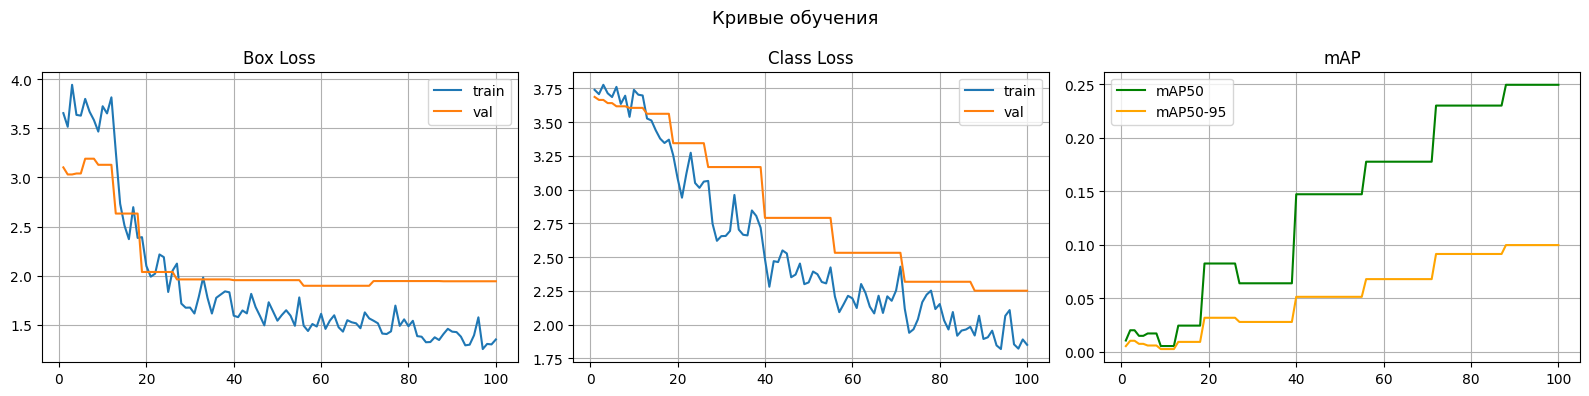


Лучший mAP50    : 0.250
Лучший mAP50-95 : 0.100


In [7]:
import pandas as pd

df = pd.read_csv(Path(result.save_dir) / "results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
if "val/box_loss" in df.columns:
    axes[0].plot(df["epoch"], df["val/box_loss"], label="val")
axes[0].set_title("Box Loss"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
if "val/cls_loss" in df.columns:
    axes[1].plot(df["epoch"], df["val/cls_loss"], label="val")
axes[1].set_title("Class Loss"); axes[1].legend(); axes[1].grid(True)

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50", color="green")
axes[2].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95", color="orange")
axes[2].set_title("mAP"); axes[2].legend(); axes[2].grid(True)

plt.suptitle("Кривые обучения", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nЛучший mAP50    : {df['metrics/mAP50(B)'].max():.3f}")
print(f"Лучший mAP50-95 : {df['metrics/mAP50-95(B)'].max():.3f}")

## 7. Метрики на валидации

In [8]:
best_model = YOLO(str(best_path))
metrics = best_model.val(data=str(yaml_path), imgsz=IMG_SIZE)

print(f"\nmAP50     : {metrics.box.map50:.3f}")
print(f"mAP50-95  : {metrics.box.map:.3f}")
print(f"Precision : {metrics.box.mp:.3f}")
print(f"Recall    : {metrics.box.mr:.3f}")
print(f"\nПо классам:")
for i, name in enumerate(CLASS_NAMES):
    try:
        print(f"  {name:<12}: mAP50={metrics.box.ap50[i]:.3f}")
    except IndexError:
        pass

Ultralytics 8.4.19 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10821MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2790.3±0.0 MB/s, size: 706.5 KB)
val: Scanning /home/user/project/yolo_dataset/labels/val.cache... 1 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1/1 161.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.2it/s 0.1s
                   all          1         53      0.404      0.246      0.252      0.103
               formula          1         28      0.544      0.357      0.343      0.173
               picture          1          4          0          0          0          0
                  text          1         21      0.669      0.381      0.414      0.136
Speed: 2.0ms preprocess, 66.4ms inference, 0.0ms loss, 9.8ms postprocess per image
Results saved to /home/user/proj

## 8. Инференс — визуализация предсказаний


image 1/1 /home/user/project/data/images/85b737ed-page_004.png: 1280x928 150 formulas, 1 picture, 149 texts, 9.8ms
Speed: 9.4ms preprocess, 9.8ms inference, 2.8ms postprocess per image at shape (1, 3, 1280, 928)


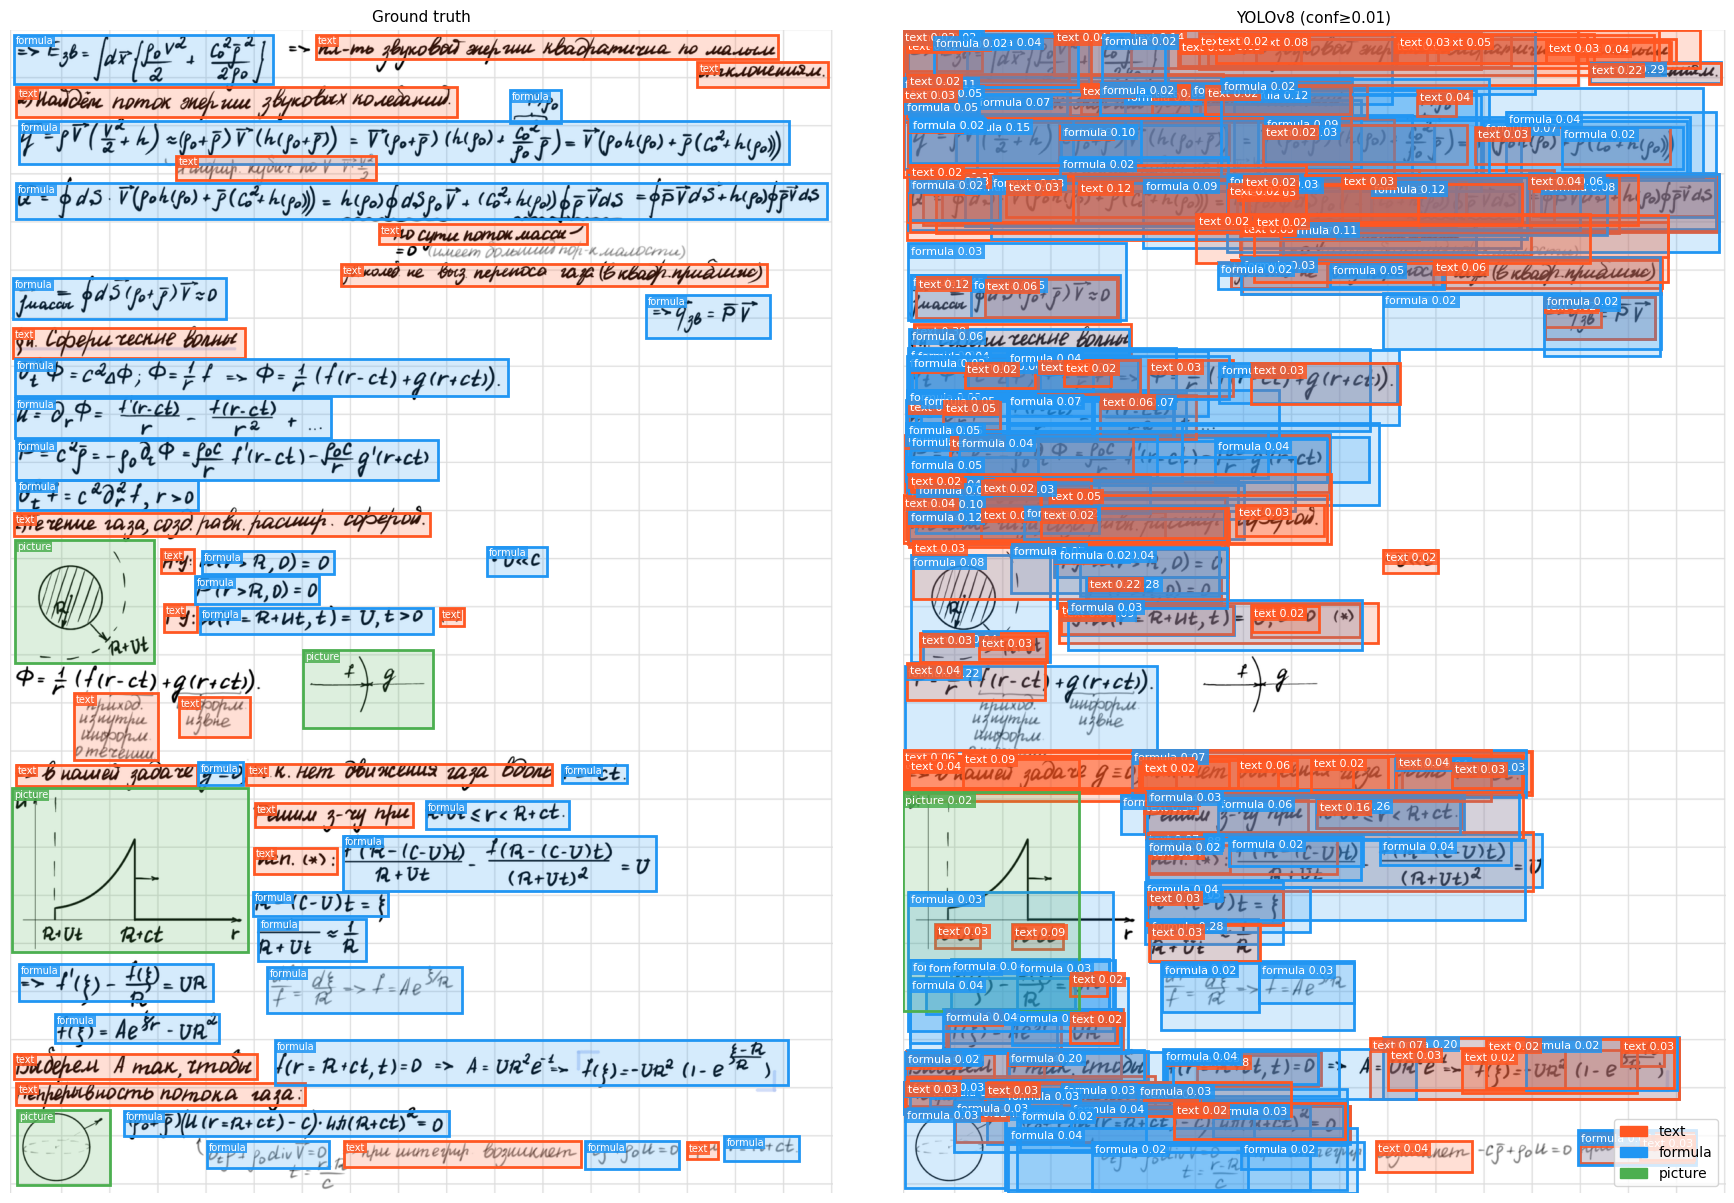

85b737ed-page_004.png: найдено 300 объектов — formula:150, text:149, picture:1


In [16]:
CONF_THRESHOLD = 0.01  # ← снизьте до 0.1 если нет детекций
TEST_PAGES     = 2      # сколько страниц показать

test_pairs = val_pairs[:TEST_PAGES]

for img_path, lbl_path in test_pairs:
    pred = best_model.predict(str(img_path), imgsz=IMG_SIZE, conf=CONF_THRESHOLD)[0]
    img  = Image.open(img_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12))

    # Ground truth
    show_labels(img_path, lbl_path, ax1)
    ax1.set_title("Ground truth", fontsize=11)

    # Предсказания
    ax2.imshow(img); ax2.axis("off")
    ax2.set_title(f"YOLOv8 (conf≥{CONF_THRESHOLD})", fontsize=11)
    seen = {}
    for box in pred.boxes:
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        x0, y0, x1, y1 = box.xyxy[0].tolist()
        color = CLASS_COLORS[cls % len(CLASS_COLORS)]
        ax2.add_patch(mpatches.Rectangle(
            (x0, y0), x1-x0, y1-y0,
            linewidth=2, edgecolor=color, facecolor=color+"30"))
        ax2.text(x0+4, y0+16, f"{CLASS_NAMES[cls]} {conf:.2f}",
                 fontsize=8, color="white",
                 bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none"))
        seen[CLASS_NAMES[cls]] = color

    if seen:
        ax2.legend(handles=[mpatches.Patch(color=c, label=l) for l,c in seen.items()],
                   loc="lower right", fontsize=10)

    plt.tight_layout()
    plt.show()

    counts = Counter(CLASS_NAMES[int(b.cls[0])] for b in pred.boxes)
    print(f"{img_path.name}: найдено {len(pred.boxes)} объектов — "
          + ", ".join(f"{n}:{c}" for n,c in counts.most_common()))